# Car Price Prediction
Steps for completing this Project
1. Loading the Dataset
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Train-validation-test split
5. Neural Network Modelling
6. Final Model + Saving

# Importing and Loading the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = 'C:/Users/Shashank/Desktop/My Folder/My-Projects/Car_Price/car_prediction_data.csv'
data = pd.read_csv(file_path)

In [3]:
print(data.to_markdown())

|     | Car_Name                  |   Year |   Selling_Price |   Present_Price |   Kms_Driven | Fuel_Type   | Seller_Type   | Transmission   |   Owner |
|----:|:--------------------------|-------:|----------------:|----------------:|-------------:|:------------|:--------------|:---------------|--------:|
|   0 | ritz                      |   2014 |            3.35 |           5.59  |        27000 | Petrol      | Dealer        | Manual         |       0 |
|   1 | sx4                       |   2013 |            4.75 |           9.54  |        43000 | Diesel      | Dealer        | Manual         |       0 |
|   2 | ciaz                      |   2017 |            7.25 |           9.85  |         6900 | Petrol      | Dealer        | Manual         |       0 |
|   3 | wagon r                   |   2011 |            2.85 |           4.15  |         5200 | Petrol      | Dealer        | Manual         |       0 |
|   4 | swift                     |   2014 |            4.6  |           6.87  |  

# Exploratory Data Analysis (EDA)

In [4]:
# Just checking the Statistics and Data Types
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [5]:
print(data.describe())

              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [6]:
print(data.describe().to_markdown())

|       |       Year |   Selling_Price |   Present_Price |   Kms_Driven |       Owner |
|:------|-----------:|----------------:|----------------:|-------------:|------------:|
| count |  301       |       301       |       301       |        301   | 301         |
| mean  | 2013.63    |         4.6613  |         7.62847 |      36947.2 |   0.0431894 |
| std   |    2.89155 |         5.08281 |         8.64412 |      38886.9 |   0.247915  |
| min   | 2003       |         0.1     |         0.32    |        500   |   0         |
| 25%   | 2012       |         0.9     |         1.2     |      15000   |   0         |
| 50%   | 2014       |         3.6     |         6.4     |      32000   |   0         |
| 75%   | 2016       |         6       |         9.9     |      48767   |   0         |
| max   | 2018       |        35       |        92.6     |     500000   |   3         |


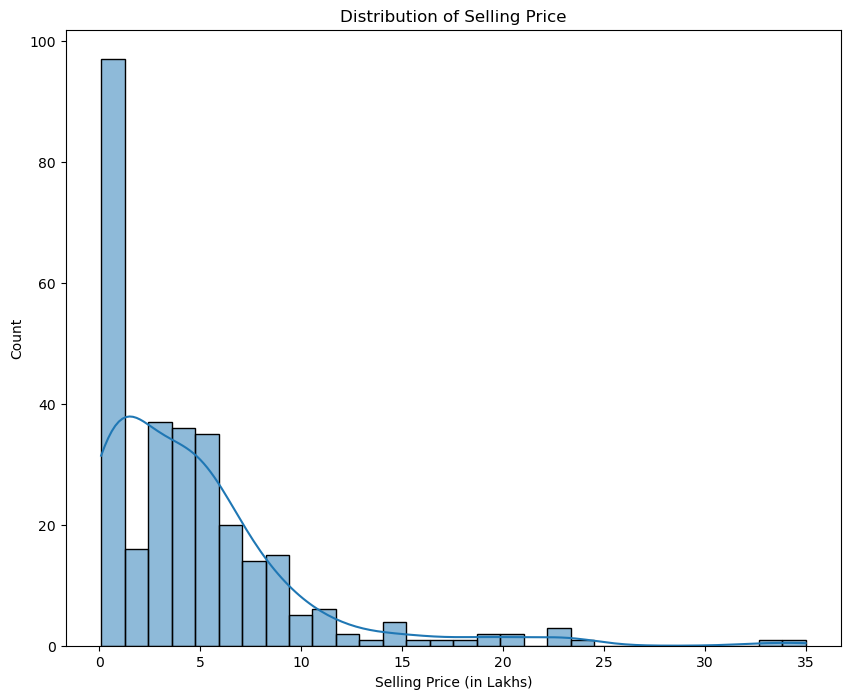

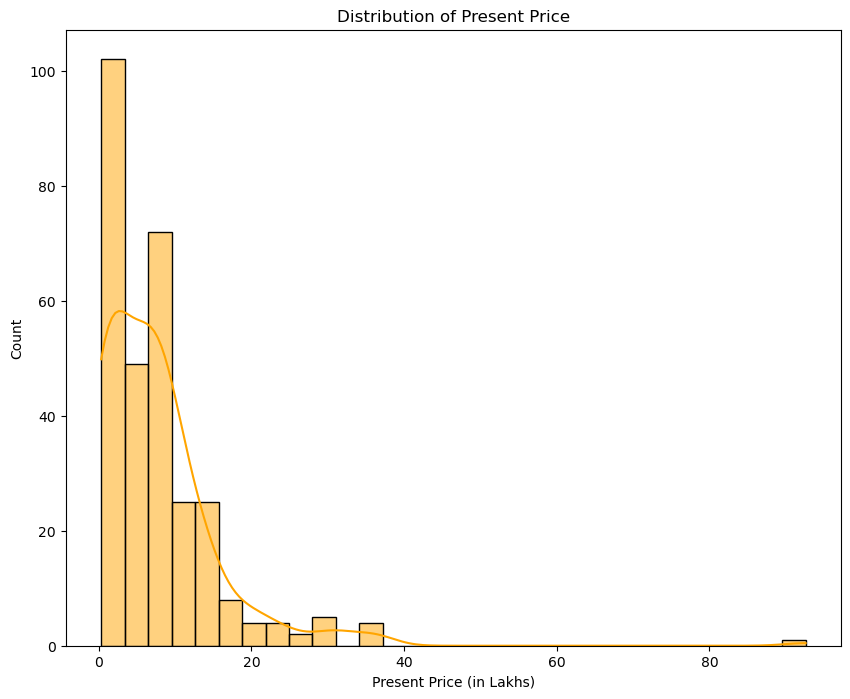

In [7]:
# Our Target Variable is Selling Price
# We will visualize the distribution of Selling Price
plt.figure(figsize = (10, 8))
sns.histplot(data['Selling_Price'], kde = True, bins = 30)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (in Lakhs)')
plt.show()

# We will also visualize the distribution of the Present Price
plt.figure(figsize = (10, 8))
sns.histplot(data['Present_Price'], kde = True, bins = 30, color = 'orange')
plt.title('Distribution of Present Price')
plt.xlabel('Present Price (in Lakhs)')
plt.show()

In [8]:
numerical_features = data.select_dtypes(include=['int64', 'float64'])
correlation_output = numerical_features.corr()['Selling_Price'].sort_values(ascending=False)
print(correlation_output)

Selling_Price    1.000000
Present_Price    0.878983
Year             0.236141
Kms_Driven       0.029187
Owner           -0.088344
Name: Selling_Price, dtype: float64


C:\Users\Shashank\AppData\Local\Temp\ipykernel_7504\3523578561.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = correlation_output.index, y = correlation_output.values, palette = 'coolwarm')


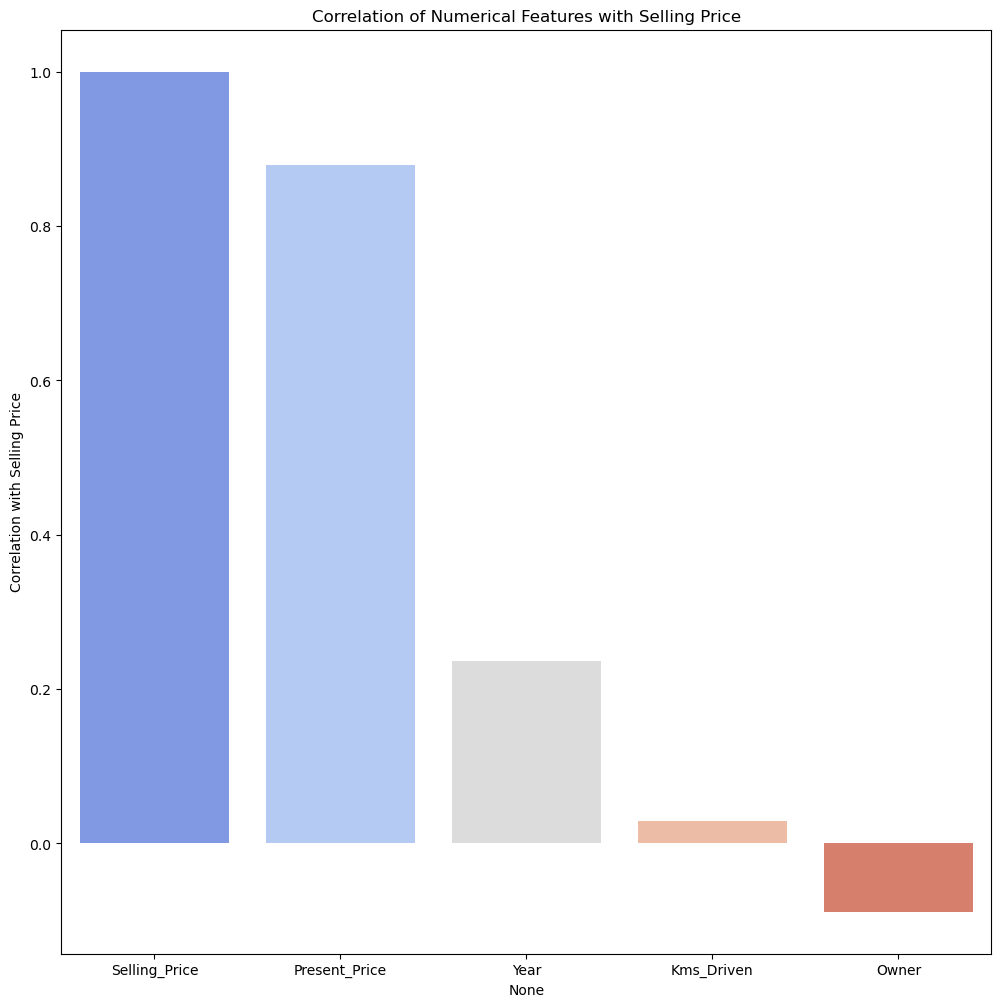

In [9]:
# finding the correlation between our selling price with our other numerical features
plt.figure(figsize = (12, 12))
sns.barplot(x = correlation_output.index, y = correlation_output.values, palette = 'coolwarm')
plt.title('Correlation of Numerical Features with Selling Price')
plt.ylabel('Correlation with Selling Price')
plt.show()

Here we can see how other numerical factors are affecting the Selling price.

In [10]:
# changing the year feature into car age
Present_Year = 2025
data['Age'] = Present_Year - data['Year']
print(data.to_markdown())

|     | Car_Name                  |   Year |   Selling_Price |   Present_Price |   Kms_Driven | Fuel_Type   | Seller_Type   | Transmission   |   Owner |   Age |
|----:|:--------------------------|-------:|----------------:|----------------:|-------------:|:------------|:--------------|:---------------|--------:|------:|
|   0 | ritz                      |   2014 |            3.35 |           5.59  |        27000 | Petrol      | Dealer        | Manual         |       0 |    11 |
|   1 | sx4                       |   2013 |            4.75 |           9.54  |        43000 | Diesel      | Dealer        | Manual         |       0 |    12 |
|   2 | ciaz                      |   2017 |            7.25 |           9.85  |         6900 | Petrol      | Dealer        | Manual         |       0 |     8 |
|   3 | wagon r                   |   2011 |            2.85 |           4.15  |         5200 | Petrol      | Dealer        | Manual         |       0 |    14 |
|   4 | swift                     

In [11]:
new_data = data.drop(['Year'], axis=1)
print(new_data.to_markdown())

|     | Car_Name                  |   Selling_Price |   Present_Price |   Kms_Driven | Fuel_Type   | Seller_Type   | Transmission   |   Owner |   Age |
|----:|:--------------------------|----------------:|----------------:|-------------:|:------------|:--------------|:---------------|--------:|------:|
|   0 | ritz                      |            3.35 |           5.59  |        27000 | Petrol      | Dealer        | Manual         |       0 |    11 |
|   1 | sx4                       |            4.75 |           9.54  |        43000 | Diesel      | Dealer        | Manual         |       0 |    12 |
|   2 | ciaz                      |            7.25 |           9.85  |         6900 | Petrol      | Dealer        | Manual         |       0 |     8 |
|   3 | wagon r                   |            2.85 |           4.15  |         5200 | Petrol      | Dealer        | Manual         |       0 |    14 |
|   4 | swift                     |            4.6  |           6.87  |        42450 | D

In [12]:
# agin checking the correlation after adding Age feature
numerical_features = new_data.select_dtypes(include=['int64', 'float64'])
correlation_output = numerical_features.corr()['Selling_Price'].sort_values(ascending=False)
print(correlation_output)

Selling_Price    1.000000
Present_Price    0.878983
Kms_Driven       0.029187
Owner           -0.088344
Age             -0.236141
Name: Selling_Price, dtype: float64


C:\Users\Shashank\AppData\Local\Temp\ipykernel_7504\1935366085.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = correlation_output.index, y = correlation_output.values, palette='coolwarm')


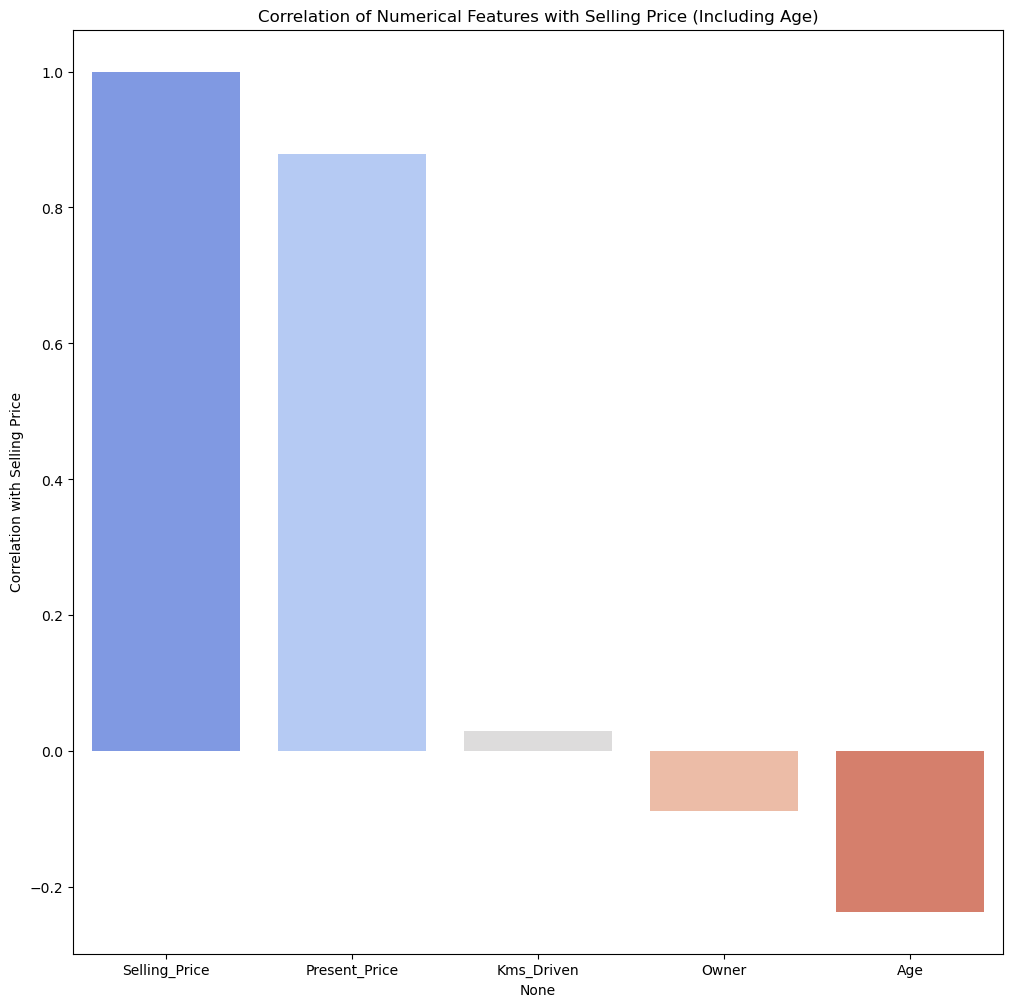

In [13]:
plt.figure(figsize = (12, 12))
sns.barplot(x = correlation_output.index, y = correlation_output.values, palette='coolwarm')
plt.title('Correlation of Numerical Features with Selling Price (Including Age)')
plt.ylabel('Correlation with Selling Price')
plt.show()

Let's Visualize the Relationship between the Categorical data with our output (Selling Price)

In [14]:
# we can use barplot as well as boxplot to visualize the categorical features against the selling price
# But I will use boxplot here
categorical_features = data[['Fuel_Type', 'Seller_Type', 'Transmission']] 
# Can also be written as data.select_dtypes(include=['object']) but this also includes 'Car_Name' which is not needed here
print(categorical_features.columns)
print(f"\n{categorical_features}")

Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object')

    Fuel_Type Seller_Type Transmission
0      Petrol      Dealer       Manual
1      Diesel      Dealer       Manual
2      Petrol      Dealer       Manual
3      Petrol      Dealer       Manual
4      Diesel      Dealer       Manual
..        ...         ...          ...
296    Diesel      Dealer       Manual
297    Petrol      Dealer       Manual
298    Petrol      Dealer       Manual
299    Diesel      Dealer       Manual
300    Petrol      Dealer       Manual

[301 rows x 3 columns]


C:\Users\Shashank\AppData\Local\Temp\ipykernel_7504\1621059555.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = data[feature], y = data['Selling_Price'], palette = 'Set3')


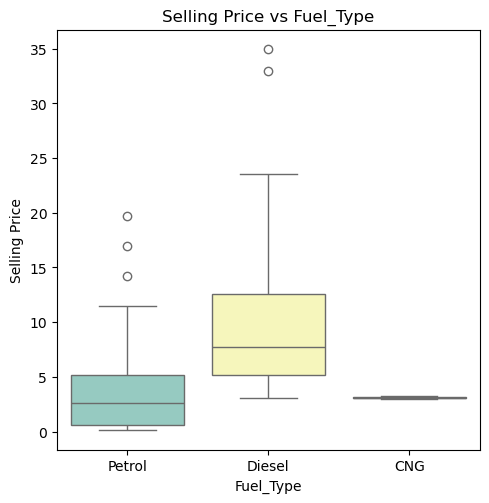

C:\Users\Shashank\AppData\Local\Temp\ipykernel_7504\1621059555.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = data[feature], y = data['Selling_Price'], palette = 'Set3')


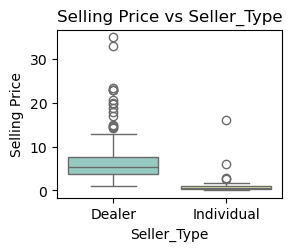

C:\Users\Shashank\AppData\Local\Temp\ipykernel_7504\1621059555.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = data[feature], y = data['Selling_Price'], palette = 'Set3')


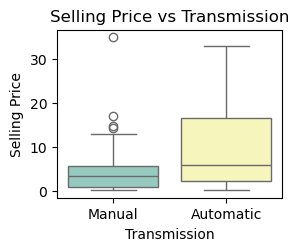

In [15]:
plt.figure(figsize = (12, 12))
for i, feature in enumerate(categorical_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x = data[feature], y = data['Selling_Price'], palette = 'Set3')
    plt.title(f'Selling Price vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Selling Price')
    plt.show()

As through this Boxplot we can spot some outliers, their are many ways of removing the outliers. But right now, I am not focusing on outliers.

# Data Preprocessing
I will be focusing in transforming the categorical data into the format which is suitable for Neural Network to understand, and engineering better features if possible.